Simulation to model muons emitted from a square source (x,y) with an angle taken from a cos^2 distribution. 

These trajectories were followed through a sphere beneath the source and the distance travelled within the sphere outputted.

say square is at z=0 position and the sphere centre is at (0,0,z=-d) position where d can be changed. 

square dimensions of 30x30cm and sphere has 30cm diameter

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Theta is the angle from the vertical.

Uniformly pick theta values from -pi/2 to pi/2

sub into PDF normalised from -pi/2 to pi/2: $f(\theta)= \frac{2}{\pi} cos^2 \theta$

pick another number, n, between 0 and 1,
keep theta if n $<cos^2\theta$

In [7]:
N=1000000
square_length = 300 #in cm
sphere_centre = np.array([0,0,-30]) #in cm
sphere_radius = 15 #in cm

x0 = np.zeros(N)
y0 = np.zeros(N)
z0 = np.zeros(N)
theta = np.zeros(N)
phi = np.zeros(N)
dx = np.zeros(N)
dy = np.zeros(N)
dz = np.zeros(N)
b = np.zeros(N)
chord = np.zeros(N)


for muon in range(N):
    x0[muon] = np.random.uniform(-square_length/2, square_length/2)
    y0[muon] = np.random.uniform(-square_length/2, square_length/2)
    z0[muon] = 0

    #angles
    accepted = False
    while not accepted:
        theta_trial = np.random.uniform(-np.pi/2, np.pi/2)
        n = np.random.uniform(0, 1)

        if n < (2/np.pi) * np.cos(theta_trial)**2:
            theta[muon] = theta_trial
            accepted = True

    phi[muon] = np.random.uniform(0,2*np.pi)

    #directions
    dx[muon] = np.sin(theta[muon])*np.cos(phi[muon])
    dy[muon] = np.sin(theta[muon])*np.sin(phi[muon])
    dz[muon] = -np.cos(theta[muon])


    #origins = (x0,y0,z0=0) = O
    #directions = (dx,dy,dz) = D
    #sphere centre = (0,0,-d) 
    O = np.array([x0[muon], y0[muon], z0[muon]])
    D = np.array([dx[muon], dy[muon], dz[muon]])
    O_C = O - sphere_centre

    b[muon] = np.linalg.norm(np.cross(O_C, D))

    chord[muon] = 0

    if b[muon] < sphere_radius:
        chord[muon] = 2*np.sqrt(sphere_radius**2 - b[muon]**2)
    else:
        chord[muon] = 0        
    


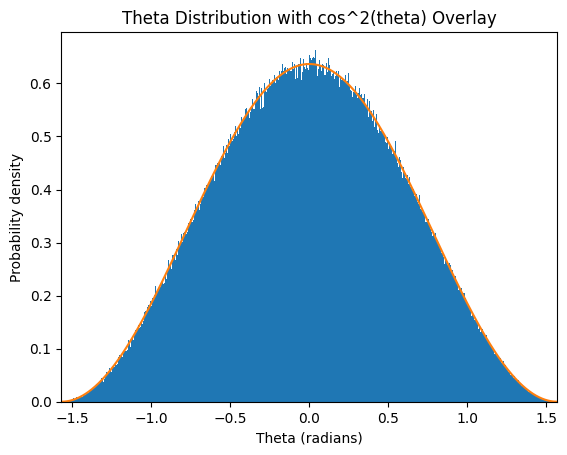

In [8]:
plt.figure()
plt.hist(theta, bins=500, density=True)

# Overlay cos^2(theta)
theta_vals = np.linspace(-np.pi/2, np.pi/2, 1000)
plt.plot(theta_vals, 2/np.pi * np.cos(theta_vals)**2)

plt.xlabel("Theta (radians)")
plt.ylabel("Probability density")
plt.title("Theta Distribution with cos^2(theta) Overlay")
plt.xlim(-np.pi/2, np.pi/2)
plt.show()

In [9]:
#print the simulated events into a table

df = pd.DataFrame({
    "x (cm)": x0,
    "y (cm)": y0,
    "z (cm)": z0,
    "theta (rad)": theta,
    "phi (rad)": phi,
    "chord length (cm)": chord,
    "closest approach to sphere centre": b
})

print(df.head())
print(np.sum(chord > 0))

      x (cm)      y (cm)  z (cm)  theta (rad)  phi (rad)  chord length (cm)  \
0  27.373113  146.205974     0.0    -0.149452   0.570260                0.0   
1  90.203139   36.874913     0.0     0.329825   5.797729                0.0   
2  45.552593  -61.560462     0.0    -0.010919   0.034211                0.0   
3 -51.851104   78.835181     0.0     0.578979   2.306457                0.0   
4 -49.942396   69.917733     0.0     0.166269   4.173634                0.0   

   closest approach to sphere centre  
0                         144.962297  
1                         101.639023  
2                          76.394809  
3                          95.562701  
4                          83.893975  
9727


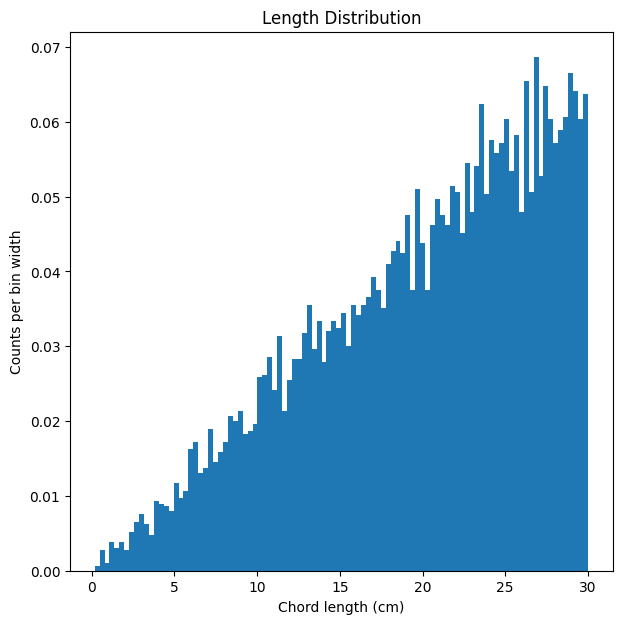

In [22]:
plt.figure(figsize=(7,7))
plt.hist(chord[chord > 0], bins=100, density=True)
plt.xlabel("Chord length (cm)")
plt.ylabel("Counts per bin width")
plt.title("Length Distribution")
plt.show()

Now analyse the amount of energy deposited in the sphere by the muons.

Find this per muon and in total. 

This will be dependent on the gas in the sphere, Nitrogen, the pressure, say 1bar, and the chord length of the muon in the sphere. 



Mass stopping power for cosmic ray muons (MIPS):

$\frac{1}{\rho}\frac{dE}{dx}=2MeV/(g/cm^2)$

find density of Nitrogen:

$pV=nRT$

$n = \frac{m}{M_r}$

$pV = \frac{m}{M_r}RT$

$\rho = \frac{m}{V}$

so: $\rho = \frac{PM_r}{RT}$


In [31]:
pressure_bar = 1 #in bars
pressure_pa = pressure_bar*(1e5)
room_temp = 293 #in Kelvin
gas_A = 28 #for N_2

dEdx_mass = 2 #MeV/gcm^2

density = (pressure_pa*gas_A)/(8.31*room_temp) / (1e6)

dEdx = dEdx_mass * density

print(dEdx,"MeV/cm")


0.0022999552330142145 MeV/cm


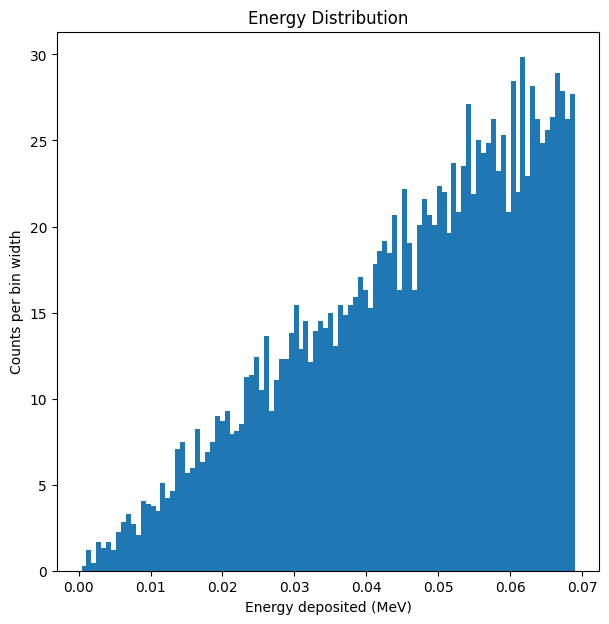

In [32]:
#multiply dE/dx by length to find dE deposited
energy_dep = dEdx * chord
plt.figure(figsize=(7,7))
plt.hist(energy_dep[energy_dep > 0], bins=100, density=True)
plt.xlabel("Energy deposited (MeV)")
plt.ylabel("Counts per bin width")
plt.title("Energy Distribution")
plt.show()


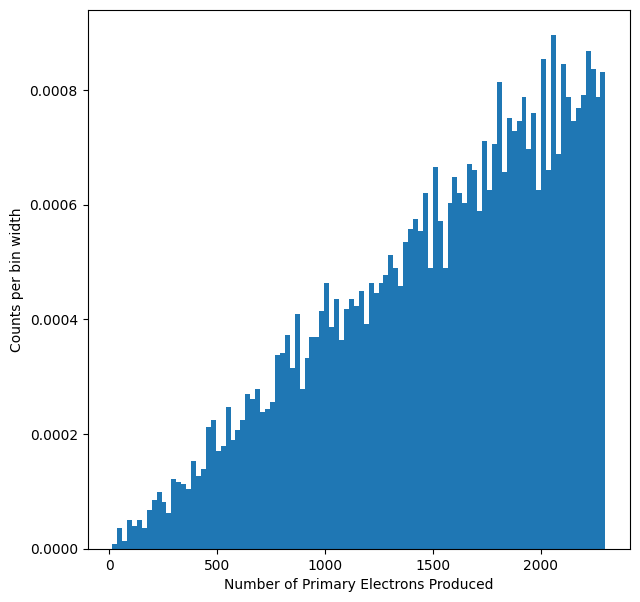

In [34]:
#use W-value to get average electrons produced, say W ~ 30eV
energy_dep_eV = energy_dep*1e6

N_primary_electrons = energy_dep_eV / 30 

plt.figure(figsize=(7,7))
plt.hist(N_primary_electrons[N_primary_electrons > 0], bins=100, density=True)
plt.xlabel("Number of Primary Electrons Produced")
plt.ylabel("Counts per bin width")
plt.show()


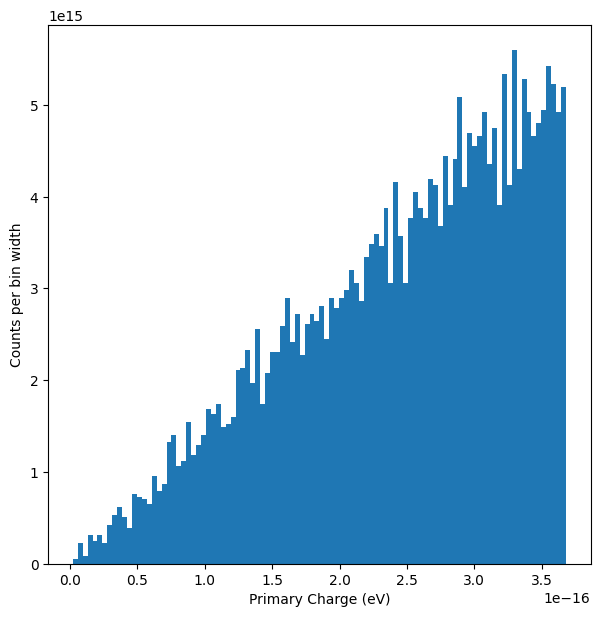

In [35]:
#convert to charge
primary_charge = N_primary_electrons * (1.6e-19)

plt.figure(figsize=(7,7))
plt.hist(primary_charge[primary_charge > 0], bins=100, density=True)
plt.xlabel("Primary Charge (eV)")
plt.ylabel("Counts per bin width")
plt.show()


Can get gain factor from Pete - multiply primary by gain factor to get charge collected at anode, then can convert to voltage readout